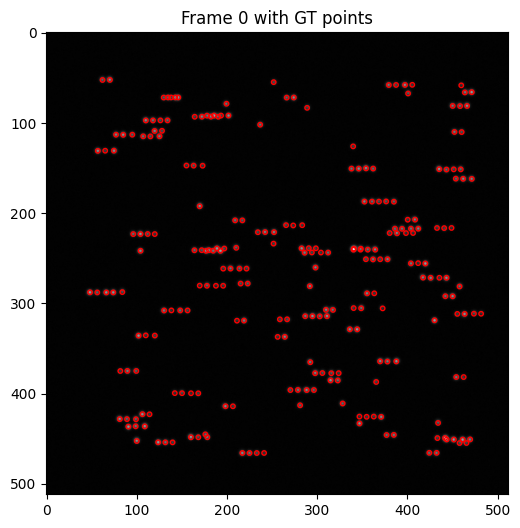

In [1]:
# Generate a synthetic tethered-strings dataset and preview
from synthetic_generator import generate_strings_stack
import imageio.v3 as iio
import matplotlib.pyplot as plt
import pandas as pd

out_tiff = 'data/synthetic_strings.tif'
out_csv = 'data/synthetic_strings_gt.csv'
# This will create the TIFF stack and ground-truth CSV
generate_strings_stack(out_tiff, out_csv)

# quick preview of frame 0
stack = iio.imread(out_tiff)
img0 = stack[100]
df = pd.read_csv(out_csv)
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img0, cmap='gray')
pts0 = df[df['frame']==100]
ax.scatter(pts0['x'], pts0['y'], s=10, facecolors='none', edgecolors='r')
ax.set_title('Frame 0 with GT points')
plt.show()

# Napari instructions: in a notebook cell run `%gui qt` then:
# import napari
# viewer = napari.Viewer()
# viewer.add_image(stack, name='synthetic')
# viewer.add_points(pts[['x','y']].values, name='gt', face_color='red')

In [2]:
# Test single-frame detection
from detect import detect_frame
from detect_utils import estimate_minmass

frame = stack[100]
diameter = 13
separation = 3

# Estimate minmass from frame
minmass = None
#print(f'Estimated minmass: {minmass:.0f}')

# Run detection
pts_det = detect_frame(
    frame,
    method='trackpy',
    diameter=diameter,
    separation=separation,
    minmass=minmass
)

print(f'Detected {len(pts_det)} particles')
print(pts_det.head())

Detected 199 particles
            x          y         mass      signal  frame
0   62.282249  51.996141  3621.785181  187.677953      0
1   69.939371  51.999233  5203.071765  273.530634      0
2  252.008166  54.995603  3178.545760  163.719066      0
3  379.428752  58.001261  4749.849474  233.599154      0
4  397.035570  57.883994  4939.524001  277.523782      0


In [3]:
# Multi-frame tracking test
from detect_utils import track_frames

start_frame = 20
end_frame = 30
diameter = 15
separation = 3

print(f'Tracking frames {start_frame} to {end_frame} (use_batch=True)...')
tracks = track_frames(
    stack,
    start_frame=start_frame,
    end_frame=end_frame,
    diameter=diameter,
    separation=separation,
    minmass=None,  # auto-estimate
    use_batch=True,
    processes=None  # auto-scale
)

print(f'Tracked {len(tracks)} detections across {end_frame - start_frame + 1} frames')
print(f'Columns: {tracks.columns.tolist()}')
print(tracks.head())

Frame 10: 2021 features
Tracked 22327 detections across 11 frames
Columns: ['frame', 'x', 'y', 'mass', 'signal']
   frame           x         y        mass    signal
0     20   58.624335  6.442661   92.798200  2.268651
1     20   92.139168  6.620313   80.138784  2.225356
2     20  210.305932  7.161549   78.684076  1.982905
3     20  228.910638  6.270306  105.327732  2.381217
4     20  246.622101  8.557361   69.817289  1.982905


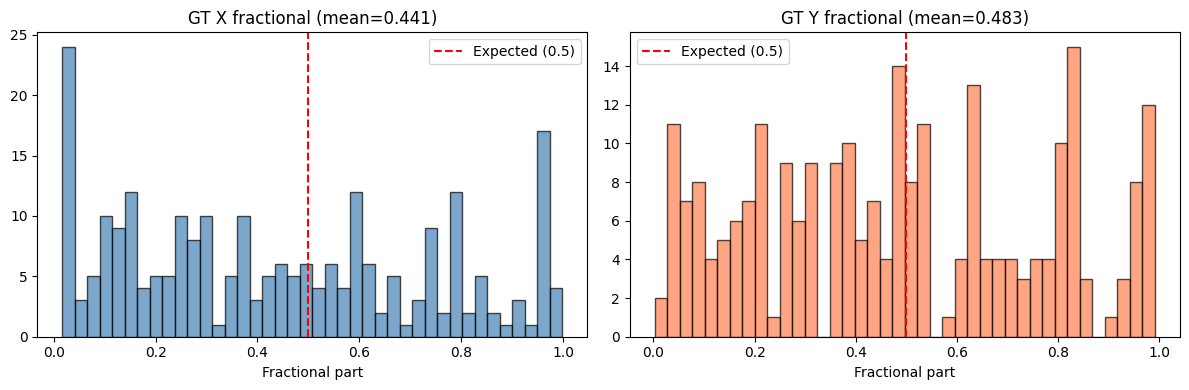

In [6]:
# Pixel bias analysis on ground truth
import numpy as np

gt_subset = df[df['frame'] == 20]
frac_x_gt = np.mod(gt_subset['x'].values, 1)
frac_y_gt = np.mod(gt_subset['y'].values, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(frac_x_gt, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0.5, color='r', linestyle='--', label='Expected (0.5)')
axes[0].set_title(f'GT X fractional (mean={np.mean(frac_x_gt):.3f})')
axes[0].set_xlabel('Fractional part')
axes[0].legend()

axes[1].hist(frac_y_gt, bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0.5, color='r', linestyle='--', label='Expected (0.5)')
axes[1].set_title(f'GT Y fractional (mean={np.mean(frac_y_gt):.3f})')
axes[1].set_xlabel('Fractional part')
axes[1].legend()

plt.tight_layout()
plt.show()

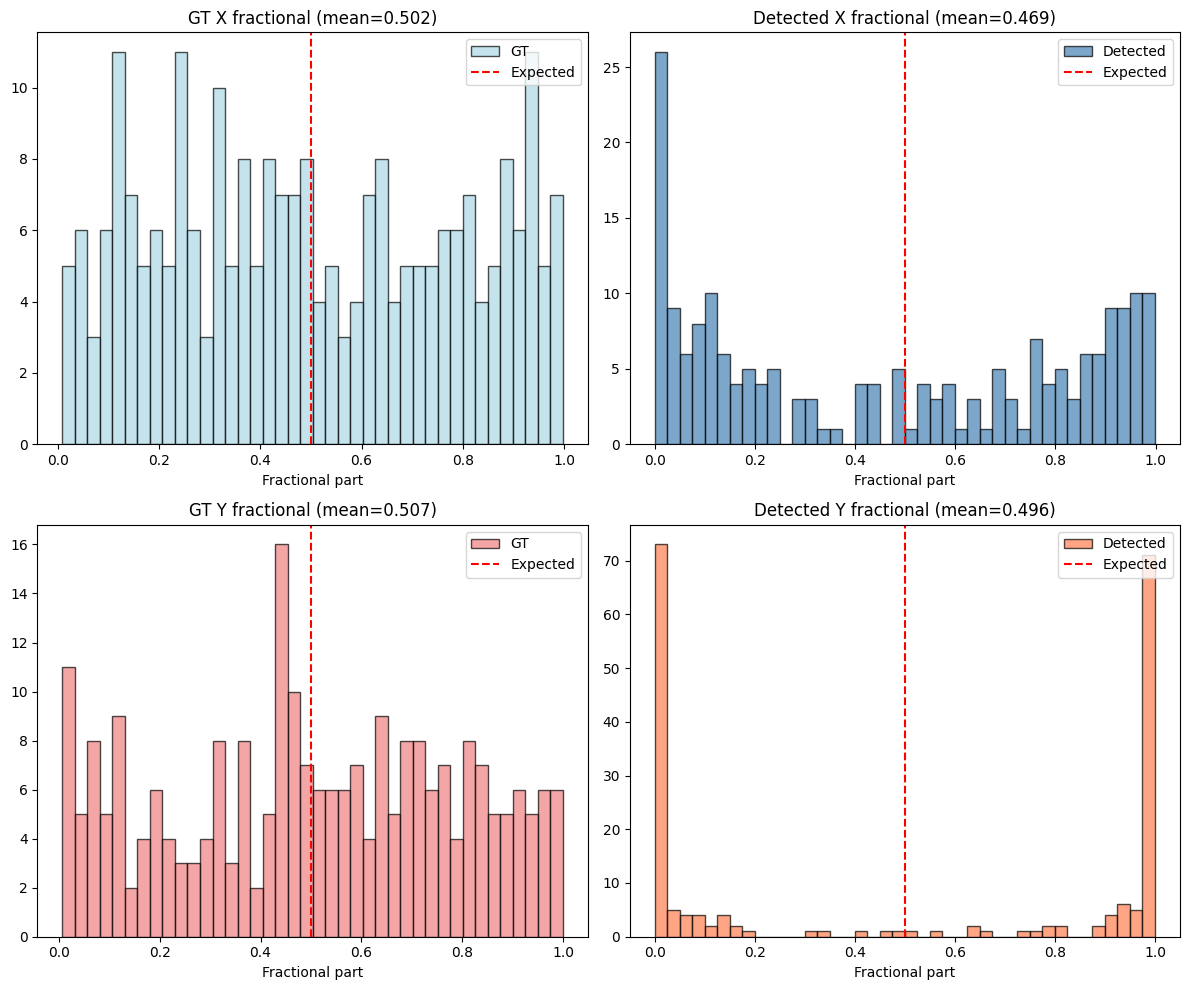

In [7]:
# Compare detected vs GT pixel bias for frame 0
gt_frame0 = df[df['frame'] == 0]
det_frame0 = pts_det

frac_x_gt = np.mod(gt_frame0['x'].values, 1)
frac_y_gt = np.mod(gt_frame0['y'].values, 1)
frac_x_det = np.mod(det_frame0['x'].values, 1)
frac_y_det = np.mod(det_frame0['y'].values, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# X histograms
axes[0, 0].hist(frac_x_gt, bins=40, edgecolor='black', alpha=0.7, color='lightblue', label='GT')
axes[0, 0].axvline(0.5, color='r', linestyle='--', label='Expected')
axes[0, 0].set_title(f'GT X fractional (mean={np.mean(frac_x_gt):.3f})')
axes[0, 0].set_xlabel('Fractional part')
axes[0, 0].legend()

axes[0, 1].hist(frac_x_det, bins=40, edgecolor='black', alpha=0.7, color='steelblue', label='Detected')
axes[0, 1].axvline(0.5, color='r', linestyle='--', label='Expected')
axes[0, 1].set_title(f'Detected X fractional (mean={np.mean(frac_x_det):.3f})')
axes[0, 1].set_xlabel('Fractional part')
axes[0, 1].legend()

# Y histograms
axes[1, 0].hist(frac_y_gt, bins=40, edgecolor='black', alpha=0.7, color='lightcoral', label='GT')
axes[1, 0].axvline(0.5, color='r', linestyle='--', label='Expected')
axes[1, 0].set_title(f'GT Y fractional (mean={np.mean(frac_y_gt):.3f})')
axes[1, 0].set_xlabel('Fractional part')
axes[1, 0].legend()

axes[1, 1].hist(frac_y_det, bins=40, edgecolor='black', alpha=0.7, color='coral', label='Detected')
axes[1, 1].axvline(0.5, color='r', linestyle='--', label='Expected')
axes[1, 1].set_title(f'Detected Y fractional (mean={np.mean(frac_y_det):.3f})')
axes[1, 1].set_xlabel('Fractional part')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Napari viewer (run in cell with %gui qt magic)
# Uncomment below to use

# %gui qt
# import napari
# viewer = napari.Viewer()
# viewer.add_image(stack, name='synthetic')
# viewer.add_points(pd.read_csv('data/synthetic_strings_gt.csv')[['x','y']].values, name='gt', face_color='red')

In [2]:
%gui qt
import napari
viewer = napari.Viewer()
stack = imageio.v3.imread('data/synthetic_strings.tif')
viewer.add_image(stack, name='synthetic')
viewer.add_points(pd.read_csv('data/synthetic_strings_gt.csv')[['x','y']].values, name='gt')

C:\Users\andyr\pyprojects\particle_tracking\.venv\Lib\site-packages\napari\_pydantic_compat.py:10: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import (


ValueError: '__slots__' in __slots__ conflicts with class variable